# GPU Checking

In [ ]:
print('Num GPUs Available:', len(tf.config.experimental.list_physical_devices('GPU')))

In [ ]:
tf.test.is_built_with_cuda()

In [ ]:
print(tf.version.VERSION)

In [ ]:
import sys
sys.version

In [ ]:
print("TF Version:", tf.__version__)
print("GPU Devices:", tf.config.list_physical_devices())
print("GPU Devices:", tf.config.list_physical_devices('GPU'))

In [ ]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

# Importing Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# Splitting data

In [7]:
(x_train,y_train),(x_test,y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 [==============================] - 410s 2us/step


In [11]:
x_train.shape

(50000, 32, 32, 3)

# Visualization

In [13]:
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [15]:
def plot_sample(index):
    plt.figure(figsize=(10,1))
    plt.title(classes[y_train[index][0] % 10]) # classes name to be included in image 
    plt.imshow(x_train[index]) # imshow = image show, used for visualization of color images

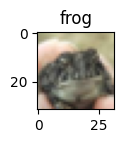

In [19]:
plot_sample(25)

# Scaling

In [21]:
x_train_scaled = x_train/255
x_test_scaled = x_test/255

# One Hot Encoding

In [23]:
y_train_categorical = keras.utils.to_categorical(
    y_train, num_classes=10
)
y_train_categorical[:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [25]:
y_test_categorical = keras.utils.to_categorical(
    y_test, num_classes=10
)
y_test_categorical[:5]

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]], dtype=float32)

# Model Creation & Compile

In [51]:
def get_model():
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=(32,32,3)), # input layer
        keras.layers.Dense(3000,activation='relu'), # hidden 1 - nodes near to input layer
        keras.layers.Dense(1000,activation='relu'), # hidden 2 - nodes are reduced from hidden 1 and near to output
        keras.layers.Dense(10,activation='sigmoid') # output layer
    ])
    
    model.compile(optimizer = 'SGD', # dataset is bigger
                 loss = "categorical_crossentropy", # when the y is one hot encoded, we can use categorical_crossentropy. When it is not, we have to use sparse_categorical_crossentropy
                 metrics=['accuracy'])
    
    model.fit(x_train_scaled, y_train_categorical, epochs=50)
    return model

# Model Saving

In [49]:
import joblib
joblib.dump(model, 'cifar10_ANN_model_joblib') # this also save in binary file

INFO:tensorflow:Assets written to: ram://507db77d-b491-4ac9-b73e-6dd7b5997256/assets


['cifar10_ANN_model_joblib']

# Model Prediction

In [33]:
predicted = model.predict(x_test_scaled)

313/313 [==============================] - 1s 4ms/step


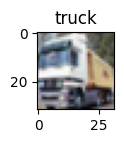

In [45]:
predict_index = 150
plot_sample(np.argmax(predicted[predict_index]))

# Model Evaluation

In [47]:
model.evaluate(x_test_scaled, y_test_categorical)

313/313 [==============================] - 2s 5ms/step - loss: 1.6201 - accuracy: 0.5577


[1.6200788021087646, 0.557699978351593]

# CPU vs GPU Performance

In [58]:
%%timeit -n1 -r1 # I don't think this line of code is working
with tf.device('/CPU:0'):
    cpu_model = get_model()
    cpu_model.fit(x_train_scaled,y_train_categorical, epochs=1)
# 42 secs

Epoch 1/50
1563/1563 [==============================] - 67s 42ms/step - loss: 1.8155 - accuracy: 0.3504
Epoch 2/50
 407/1563 [======>.......................] - ETA: 49s - loss: 1.6532 - accuracy: 0.4139 

KeyboardInterrupt: 

In [60]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
    cpu_model = get_model()
    cpu_model.fit(x_train_scaled,y_train_categorical, epochs=1)
# 7 secs

Epoch 1/50
1563/1563 [==============================] - 11s 7ms/step - loss: 1.8081 - accuracy: 0.3587
Epoch 2/50
1363/1563 [=========================>....] - ETA: 1s - loss: 1.6217 - accuracy: 0.4288 

KeyboardInterrupt: 

My GPU is 6 times faster than CPU